# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 7.6 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

As shown during the loading of the data through `df.info()`, there are no missing values. 
So, we can focus on other characteristics of the data.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

First, let's observe the unique values of the categorical data.

In [5]:
df['Division Name'].value_counts(normalize=True)

Division Name
General           0.632469
General Petite    0.367531
Name: proportion, dtype: float64

In [6]:
df['Department Name'].value_counts(normalize=True)

Department Name
Tops        0.472454
Dresses     0.291237
Bottoms     0.172649
Jackets     0.047663
Intimate    0.010194
Trend       0.005802
Name: proportion, dtype: float64

In [7]:
df['Class Name'].value_counts(normalize=True)

Class Name
Dresses           0.291237
Knits             0.215866
Blouses           0.140278
Sweaters          0.066045
Pants             0.062737
Jeans             0.052597
Fine gauge        0.050266
Skirts            0.043162
Jackets           0.032426
Outerwear         0.015237
Shorts            0.014098
Lounge            0.010194
Trend             0.005802
Casual bottoms    0.000054
Name: proportion, dtype: float64

Text(0, 0.5, 'Frequency')

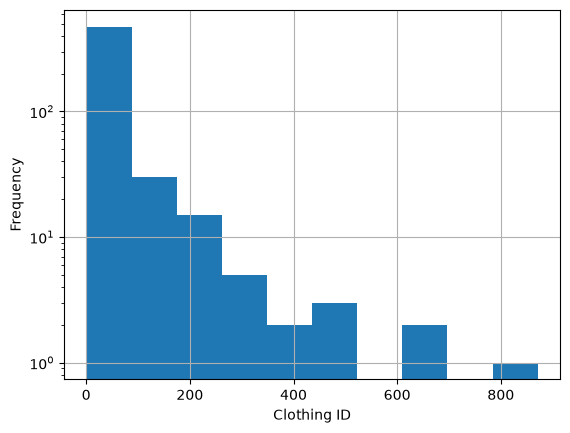

In [8]:
df['Clothing ID'].value_counts(normalize=False).hist(log=True)
plt.xlabel("Clothing ID")
plt.ylabel("Frequency")

In [9]:
print("Total number of cloths (by Clothind ID):", len(df['Clothing ID'].unique()))

Total number of cloths (by Clothind ID): 531


Note that, despite `Clothing ID` being a numerical column, the info is, in fact, categorical.
However, using a `OneHotEncoder` probably would not be feasible because it would increase the table with +500 features.
I would keep it numerical, or simply exclude it from the analysis.


In [10]:
print("Total of", df.duplicated().sum(), "duplicated data")

Total of 0 duplicated data


Now analysing the numericla data.

<Axes: ylabel='Frequency'>

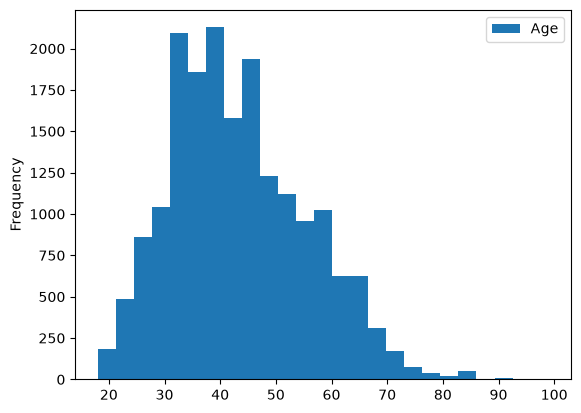

In [11]:
df.plot(kind="hist", y="Age", bins=25)

<Axes: ylabel='Frequency'>

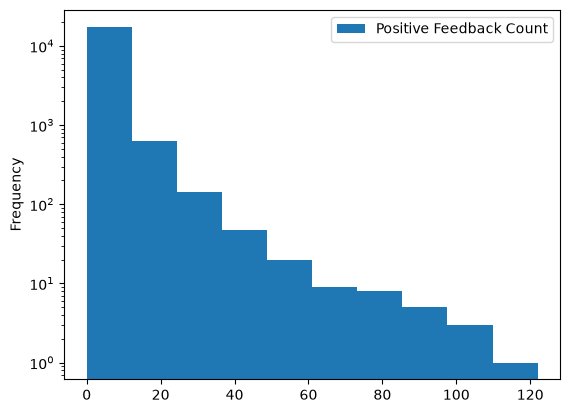

In [12]:
df.plot(kind="hist", y="Positive Feedback Count", log=True)

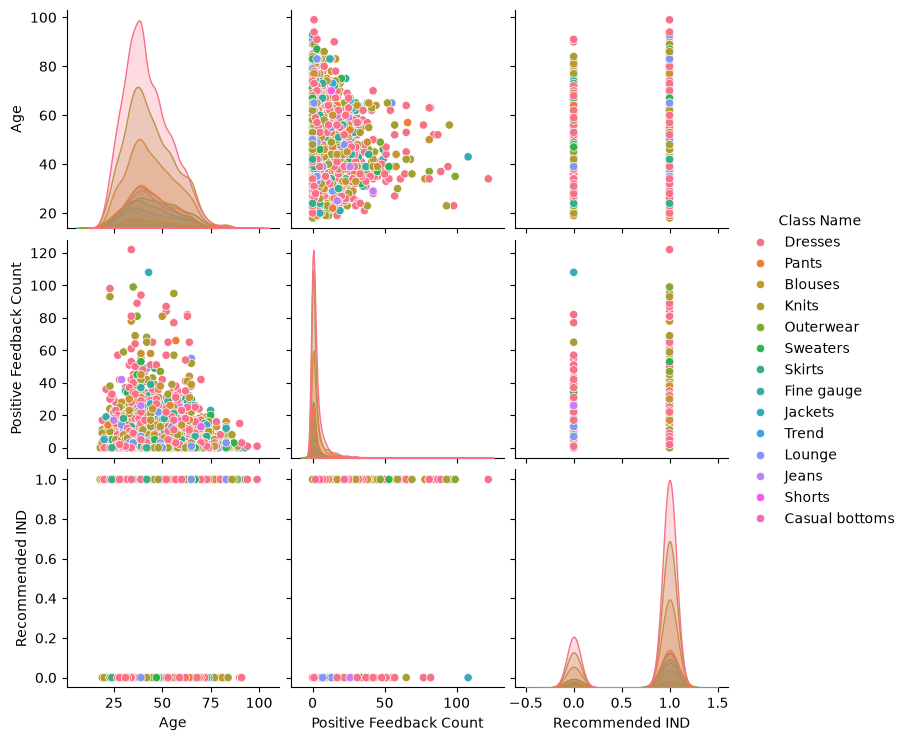

In [13]:
sns.pairplot(df, hue="Class Name", vars=["Age", 'Positive Feedback Count', 'Recommended IND'])

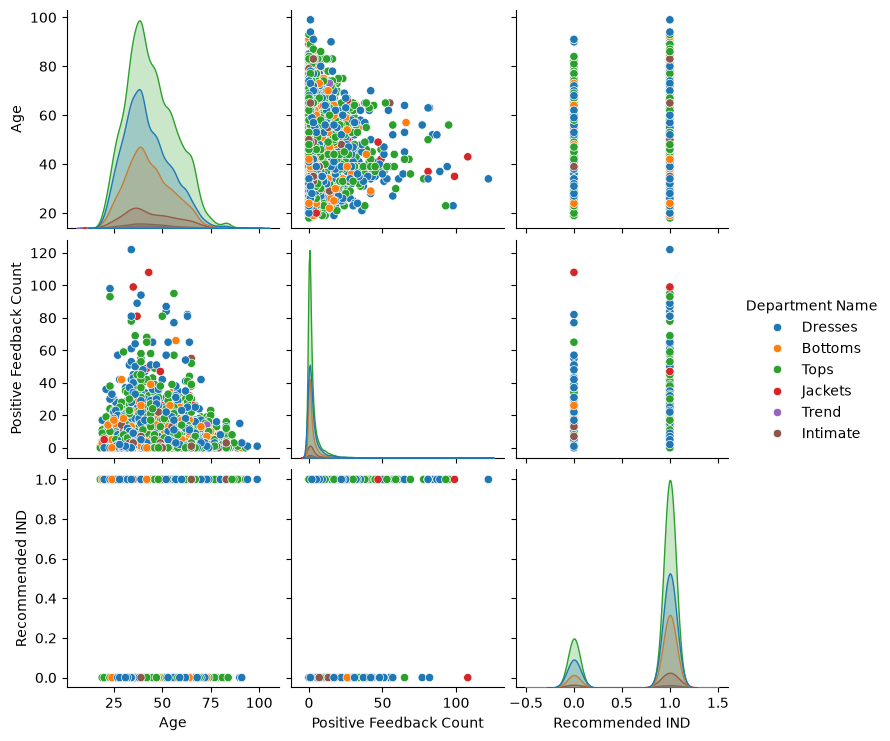

In [14]:
sns.pairplot(df, hue="Department Name", vars=["Age", 'Positive Feedback Count', 'Recommended IND'])

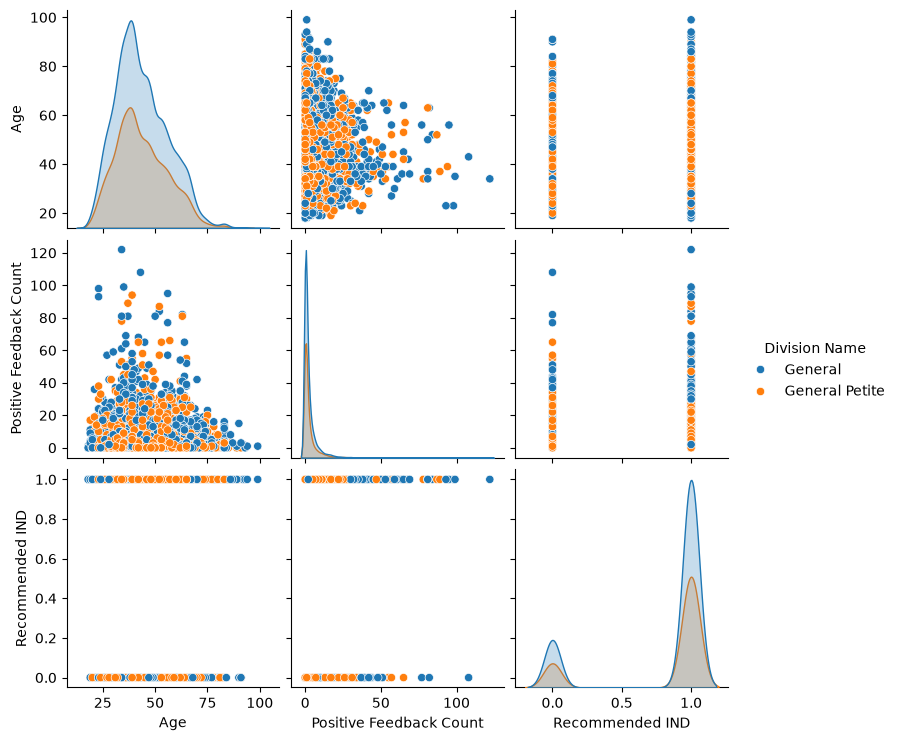

In [15]:
sns.pairplot(df, hue="Division Name", vars=["Age", 'Positive Feedback Count', 'Recommended IND'])

<Axes: >

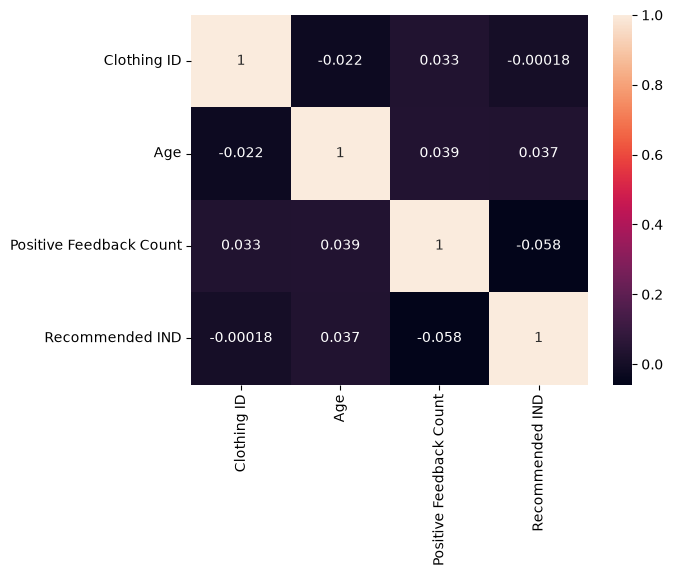

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [41]:
balance_RecIND = df['Recommended IND'].value_counts(normalize=True)
balance_RecIND

Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64

This info shows that the data is imbalanced towards the recommendation.
This indicates that the number of false positives and false negatives must be specifically addressed in the ML model.

## Building Pipeline

### Pre-processing

In [17]:
X.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Positive Feedback Count',
       'Division Name', 'Department Name', 'Class Name'],
      dtype='str')

In [18]:
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [19]:
num_cols = ['Age', 'Positive Feedback Count']
cat_cols = ['Division Name', 'Department Name', 'Class Name']
text_cols = ['Title', 'Review Text']
# Clothing ID is not explicitely used in the analysis, therefore it is ignored (I think)

In [42]:
num_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy="mean")), # useless, since no missing values exists
        ('scaler', StandardScaler())
    ]
)
# num_pipeline

In [43]:
cat_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)
# cat_pipeline

In [22]:
num_pipeline.fit_transform(X_train[num_cols]).shape

(16597, 2)

In [23]:
cat_pipeline.fit_transform(X_train[cat_cols])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 49791 stored elements and shape (16597, 22)>

In [24]:
import spacy
import numpy as np

# ! python -m spacy download en_core_web_sm

nlp = spacy.load('en_core_web_sm')

In [45]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer

class CountCharacter(BaseEstimator, TransformerMixin):
    """
    Count Character
    ===============

    Count the number of given character in every cell of a list of strings.
    Use `transform` method to perform this task.

    Params
    ------
    character : str
        Character to be search.
    X : list[str]
        1-D array of strings. Attribute of `transform` method.
    
    Return
    ------
    counts_list : list[int]
        Number of appearances of `character` of each element in X.
    """
    def __init__(self, character: str):
        self.character = character

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [[text.count(self.character)] for text in X]

initial_text_preprocess = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'shape':-1},
        ),
    ),
])

count_featunion = FeatureUnion(
    [
        ('count_spaces', CountCharacter(character=' ')),
        ('count_exclamations', CountCharacter(character='!')),
        ('count_question_marks', CountCharacter(character='?')),
    ]
)

charcount_pipeline = Pipeline(
    [
        ('initial_text', initial_text_preprocess),
        ('counting_text', count_featunion)
    ] 
)
# charcount_pipeline

In [46]:
initial_text_preprocess.fit_transform(X_train[text_cols[0]]).shape

(16597,)

In [47]:
class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    """
    SpaCy Lemmatizer
    ================

    Lematize a column of texts with SpaCy.
    Use `transform` method to perform this task.

    Params
    ------
    nlp : SpaCy object
        Natural language process object.
    X : list[str]
        1-D array of strings. Attribute of `transform` method.
    
    Return
    ------
    lemmatized : list[str]
        Lemmatized array of X.
    """
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatized = [
            ' '.join(
                token.lemma_ for token in doc
                if not token.is_stop
            )
            for doc in self.nlp.pipe(X)
        ]
        return lemmatized 

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pipeline = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'shape':-1},
        ),
    ),
    (
        'lemmatizer',
        SpacyLemmatizer(nlp=nlp),
    ),
    (
        'tfidf_vectorizer',
        TfidfVectorizer(
            stop_words='english',
        ),
    ),
])
# tfidf_pipeline

In [49]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    [
        ('Numerical', num_pipeline, num_cols),
        ('Categorical', cat_pipeline, cat_cols),
        ('Title_CharCount', charcount_pipeline, text_cols[0]),
        ('Title_tfidf', tfidf_pipeline, text_cols[0]),
        ('Review_CharCount', charcount_pipeline, text_cols[1]),
        # ('Review_tfidf', tfidf_pipeline, text_cols[1]) # with that, the code is taking 3+ minutes, with an accuracy of 0.8617886178861789.
    ]
)
preprocessor

ColumnTransformer(transformers=[('Numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Positive Feedback Count']),
                                ('Categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Division Name', 'Department Name',
                                  'Class Name']),
                                ('Title_CharCou...
                                 Pipeline(steps=[('initial_text',
                                                  Pipeline(steps=[('dimension_reshaper',
                                                                   FunctionTransformer(func=<function reshape at 0x106ec4770>,
                                                                                       kw_args={'shape': -1}))])),
                                                 ('counting_text',
                                                  FeatureUnion(transformer_list=[('count_spaces',
                                                                                  CountCharacter(character=' ')),
                                                                                 ('count_exclamations',
                                                                                  CountCharacter(character='!')),
                                                                                 ('count_question_marks',
                                                                                  CountCharacter(character='?'))]))]),
                                 'Review Text')])

### Modeling

Here we are going to address the machine learning modeling itself, comparing some models and considering the imbalanced data.

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.pipeline import make_pipeline

In [114]:
logregression_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(random_state=6577, verbose=0, class_weight='balanced') 
)
svc_pipeline = make_pipeline(
    preprocessor,
    SVC(random_state=6577, verbose=0, class_weight='balanced') 
)
randomforest_pipeline = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=6577, verbose=0, class_weight='balanced') 
)
gradientbooster_pipeline = make_pipeline(
    preprocessor,
    GradientBoostingClassifier(random_state=6577, verbose=0) 
)

## Training Pipeline

In [143]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from time import perf_counter

def analyse_model(model_pipeline):
    """
    Compute the train and test accuracies and the f1-score of 
    a trained model.
    """

    start = perf_counter()
    y_test_pred = model_pipeline.predict(X_test)
    end = perf_counter()

    prediction_time = end - start
    
    _train_score = model_pipeline.score(X_train, y_train)
    _test_score = accuracy_score(y_test, y_test_pred)
    _precision = precision_score(y_test, y_test_pred)
    _recall = recall_score(y_test, y_test_pred)
    _f1 = f1_score(y_test, y_test_pred)

    print(f"Prediction time: {prediction_time:.4f}s")
    print(f"Train and test scores: {_train_score:.3f}/{_test_score:.3f}")
    print(f"Precision and recall: {_precision:.3f}/{_recall:.3f}")
    print(f"f1-score: {_f1:.4f}")
    
    plt.figure(figsize=(1.5,1.5))
    sns.heatmap(
        confusion_matrix(y_test, y_test_pred, normalize='all'), 
        cbar=False, annot=True, cmap="Blues", linecolor="gray", linewidth=.3
    )
    plt.xlabel("Predicted values")
    plt.ylabel("Actual values")

    return prediction_time, _train_score, _test_score, _precision, _recall, _f1

/Users/felipegiro/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/Users/felipegiro/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Prediction time: 1.7775s
Train and test scores: 0.769/0.766
Precision and recall: 0.769/0.766
f1-score: 0.8411
CPU times: user 36 s, sys: 1.81 s, total: 37.8 s
Wall time: 33.3 s


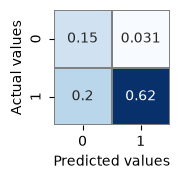

In [129]:
%%time
logregression_pipeline.fit(X_train, y_train)
logregression_summary = analyse_model(logregression_pipeline)

Prediction time: 3.2338s
Train and test scores: 0.514/0.526
Precision and recall: 0.514/0.526
f1-score: 0.6187
CPU times: user 1min 7s, sys: 1.38 s, total: 1min 8s
Wall time: 1min 8s


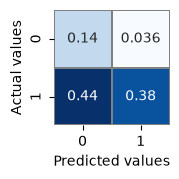

In [130]:
%%time
svc_pipeline.fit(X_train, y_train)
svc_summary = analyse_model(svc_pipeline)

Prediction time: 1.7328s
Train and test scores: 1.000/0.866
Precision and recall: 1.000/0.866
f1-score: 0.9217
CPU times: user 38.5 s, sys: 774 ms, total: 39.3 s
Wall time: 39.4 s


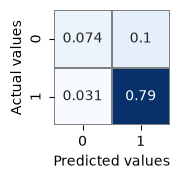

In [131]:
%%time
randomforest_pipeline.fit(X_train, y_train)
randomforest_summary = analyse_model(randomforest_pipeline)

Prediction time: 1.6422s
Train and test scores: 0.852/0.846
Precision and recall: 0.852/0.846
f1-score: 0.9138
CPU times: user 33.4 s, sys: 719 ms, total: 34.1 s
Wall time: 34.4 s


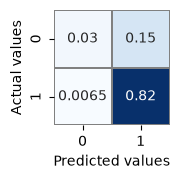

In [132]:
%%time
gradientbooster_pipeline.fit(X_train, y_train)
gradientbooster_summary = analyse_model(gradientbooster_pipeline)

In [133]:
df_summary = pd.DataFrame(
    data = [
        logregression_summary, 
        svc_summary, 
        randomforest_summary, 
        gradientbooster_summary
    ],
    columns = [
        "Prediction time (s)", "Train score", "Test score", "Precision", "Recall" ,"F1 score"
    ],
    index = [
        "Logistic Regression", "SVC", "Random Forest", "Gradient Booster"
    ]
)
df_summary

,Prediction time (s),Train score,Test score,Precision,Recall,F1 score
Logistic Regression,1.777538,0.768934,0.765854,0.952500,0.752964,0.841060
SVC,3.233770,0.513828,0.525745,0.913771,0.467721,0.618736
Random Forest,1.732843,1.000000,0.865583,0.884848,0.961792,0.921717
Gradient Booster,1.642244,0.851841,0.846070,0.847019,0.992095,0.913835


So, the data shows us:
- **Logistic regression** shows no signs of overfitting (similar train and test scores). Perhaps a slight underfitting because their scores are around 76%, which it could be improved through a hyperparameters search.
- **SVC** had a very poor performance in general.
- **Random forest** shows clear signs of overfitting (train score is 100%).
- **Gradient booster** presents similar results as logistic regression but with better scores in general.

Basically, the choice is between **logistic regression** and **gradient booster**, with the trade-off between precision and recall.
Worth remembering the definition of these quantities:
- *Precision* means the correct prediction out of all positive predictions.
- *Recall* means the correct prediction out of all real positives.

Choosing precision over recall, we have to be tolerant with false negatives. On the other hand, choosing recall over precision demands a higher tolerance with false positives.

Let's come back to the business question and set a quality criteria. I don't want to overflow the user with meaningless recommendations; rather, I want to reduce the false positives as far as possible. Therefore, our preference is for a model with a high recall score, which is, in our case, the Gradient Booster.

In [134]:
# choosing the prefered model
model_pipeline = gradientbooster_pipeline

## Fine-Tuning Pipeline

In [135]:
model_pipeline.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('Numerical',
                                    Pipeline(steps=[('imputer', SimpleImputer()),
                                                    ('scaler', StandardScaler())]),
                                    ['Age', 'Positive Feedback Count']),
                                   ('Categorical',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('encoder',
                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                    ['Division Name', 'Department Name',
                                     'Class Name']),
                                   ('Title_CharCou...
                                    Pipeline(steps=[('initial_text',
                                           

Let's focus on the hyperparameters of the model.

In [136]:
from sklearn.model_selection import RandomizedSearchCV

params_dict = {
    'gradientboostingclassifier__learning_rate' : [.01, .1, 1, 3],
    'gradientboostingclassifier__ccp_alpha' : [0, .1, 1],
    'gradientboostingclassifier__max_features' : ['sqrt', 'log2', None],
    'gradientboostingclassifier__n_estimators' : [50, 100, 200]
}

params_search = RandomizedSearchCV(
    estimator = model_pipeline,
    param_distributions = params_dict,
    n_iter = 20,
    cv=5,
    verbose=3
)
params_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END gradientboostingclassifier__ccp_alpha=1, gradientboostingclassifier__learning_rate=0.1, gradientboostingclassifier__max_features=None, gradientboostingclassifier__n_estimators=100;, score=0.815 total time=  18.0s
[CV 2/5] END gradientboostingclassifier__ccp_alpha=1, gradientboostingclassifier__learning_rate=0.1, gradientboostingclassifier__max_features=None, gradientboostingclassifier__n_estimators=100;, score=0.815 total time=  17.5s
[CV 3/5] END gradientboostingclassifier__ccp_alpha=1, gradientboostingclassifier__learning_rate=0.1, gradientboostingclassifier__max_features=None, gradientboostingclassifier__n_estimators=100;, score=0.816 total time=  17.4s
[CV 4/5] END gradientboostingclassifier__ccp_alpha=1, gradientboostingclassifier__learning_rate=0.1, gradientboostingclassifier__max_features=None, gradientboostingclassifier__n_estimators=100;, score=0.816 total time=  17.7s
[CV 5/5] END gradientboostingclass

/Users/felipegiro/anaconda3/lib/python3.14/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('Numerical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Positive '
                                                                                'Feedback '
                                                                                'Count']),
                                                                              ('Categorical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown=...
                                             ('gradientboostingclassifier',
                                              GradientBoostingClassifier(random_state=6577))]),
                   n_iter=20,
                   param_distributions={'gradientboostingclassifier__ccp_alpha': [0,
                                                                                  0.1,
                                                                                  1],
                                        'gradientboostingclassifier__learning_rate': [0.01,
                                                                                      0.1,
                                                                                      1,
                                                                                      3],
                                        'gradientboostingclassifier__max_features': ['sqrt',
                                                                                     'log2',
                                                                                     None],
                                        'gradientboostingclassifier__n_estimators': [50,
                                                                                     100,
                                                                                     200]},
                   verbose=3)

In [150]:
params_search

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('Numerical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Positive '
                                                                                'Feedback '
                                                                                'Count']),
                                                                              ('Categorical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown=...
                                             ('gradientboostingclassifier',
                                              GradientBoostingClassifier(random_state=6577))]),
                   n_iter=20,
                   param_distributions={'gradientboostingclassifier__ccp_alpha': [0,
                                                                                  0.1,
                                                                                  1],
                                        'gradientboostingclassifier__learning_rate': [0.01,
                                                                                      0.1,
                                                                                      1,
                                                                                      3],
                                        'gradientboostingclassifier__max_features': ['sqrt',
                                                                                     'log2',
                                                                                     None],
                                        'gradientboostingclassifier__n_estimators': [50,
                                                                                     100,
                                                                                     200]},
                   verbose=3)

In [139]:
best_pipeline = params_search.best_estimator_

Prediction time: 1.6220s
Train and test scores: 0.913/0.860
Precision and recall: 0.897/0.937
f1-score: 0.9165


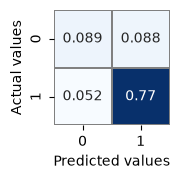

In [146]:
best_summary = analyse_model(best_pipeline)

In [148]:
df_summary.loc["Gradient Booster (searched)"] = best_summary
df_summary

,Prediction time (s),Train score,Test score,Precision,Recall,F1 score
Logistic Regression,1.777538,0.768934,0.765854,0.952500,0.752964,0.841060
SVC,3.233770,0.513828,0.525745,0.913771,0.467721,0.618736
Random Forest,1.732843,1.000000,0.865583,0.884848,0.961792,0.921717
Gradient Booster,1.642244,0.851841,0.846070,0.847019,0.992095,0.913835
Gradient Booster (searched),1.621984,0.913117,0.859621,0.897161,0.936759,0.916532


Given these results, observe that:
- The searched model increased all scores at the expense of recall, which was important to the business criteria.
- The searched model has poorer generalization, shown in the difference of 5 points between train and test accuracy.

The gain in precision and accuracy does not justify the loss of the recall score.
Together with the poor generalization, we decided to keep with the original model.

In [153]:
import pickle

with open("svc.pkl", "wb") as f:
    pickle.dump(gradientbooster_pipeline, f) # original Bradient Boosteing was chosen